# Fraud Detection — Layer 2
## Notebook 4: Order Fraud Detection
**Author:** Frederick Amartey-Fio  
**Institution:** JUNIA ISEN — MSc Big Data  
**Date:** May 2026

---

### Objective
Build a second fraud detection layer that catches fraudulent orders
even when a stolen card passes Layer 1 (credit card check).

Layer 2 analyzes behavioural signals at the order level:
- Account age and history
- Email type and identity consistency
- Shipping patterns and destination
- Device and IP velocity
- Product category risk
- Billing and account name consistency

Each signal contributes to a risk score between 0 and 100.
The final decision is: **Approve / Review / Decline**

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — IMPORTS
# Layer 2 is a rule-based scoring engine written in pure Python.
# No ML libraries needed — just pandas and dataclasses.
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass, field
from typing import List, Tuple

%matplotlib inline
sns.set_style("whitegrid")

print("Libraries loaded.")

Libraries loaded.


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — ORDER DATA STRUCTURE
# We define what an "order" looks like to our system.
# Every order that comes in will have these fields.
# The scoring engine reads these fields and assigns a risk score.
# ─────────────────────────────────────────────────────────────

@dataclass
class Order:
    # Account signals
    account_age_days: int        # how old is the account
    total_past_orders: int       # how many orders has this account placed before

    # Email signals
    email_type: str              # "established", "disposable", "random"

    # Shipping signals
    shipping_country: str        # "same", "different", "high_risk"
    shipping_method: str         # "standard", "express", "freight_forwarder"

    # IP and device signals
    orders_same_ip_today: int    # how many orders from this IP today
    vpn_detected: bool           # is a VPN or proxy being used

    # Product signals
    product_category: str        # "normal", "elevated", "high_risk"
    order_amount: float          # total order value in dollars

    # Identity signals
    address_added_recently: bool  # was shipping address added in last 10 mins
    multiple_cards_tried: bool    # were multiple cards attempted
    name_mismatch: bool           # billing name differs from account name
    linked_to_prior_fraud: bool   # email or phone tied to known fraud

print("Order data structure defined.")
print()
print("Fields:")
for field_name, field_type in Order.__annotations__.items():
    print(f"  {field_name}: {field_type}")

Order data structure defined.

Fields:
  account_age_days: <class 'int'>
  total_past_orders: <class 'int'>
  email_type: <class 'str'>
  shipping_country: <class 'str'>
  shipping_method: <class 'str'>
  orders_same_ip_today: <class 'int'>
  vpn_detected: <class 'bool'>
  product_category: <class 'str'>
  order_amount: <class 'float'>
  address_added_recently: <class 'bool'>
  multiple_cards_tried: <class 'bool'>
  name_mismatch: <class 'bool'>
  linked_to_prior_fraud: <class 'bool'>


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — SCORING ENGINE
# Each signal adds points to a risk score (0-100).
# Higher score = higher fraud risk.
# Each rule returns a score contribution and an explanation.
# ─────────────────────────────────────────────────────────────

def score_order(order: Order) -> Tuple[int, List[dict]]:
    """
    Takes an Order object and returns:
    - score (int): risk score between 0 and 100
    - signals (list): explanation of what drove the score
    """
    score = 0
    signals = []

    # ── Account age ──────────────────────────────────────────
    if order.account_age_days < 1:
        score += 22
        signals.append({"level": "high", "text": "Account created today",
                        "reason": "Fresh accounts placing immediate orders are a top fraud signal"})
    elif order.account_age_days < 7:
        score += 14
        signals.append({"level": "high", "text": f"Account only {order.account_age_days} day(s) old",
                        "reason": "Very new account — identity not yet established"})
    elif order.account_age_days < 30:
        score += 6
        signals.append({"level": "medium", "text": f"Account {order.account_age_days} days old",
                        "reason": "New account — moderate concern"})
    else:
        signals.append({"level": "low", "text": f"Established account ({order.account_age_days} days)",
                        "reason": "Account history reduces fraud likelihood"})

    # ── Order history ─────────────────────────────────────────
    if order.total_past_orders == 0:
        score += 10
        signals.append({"level": "medium", "text": "First order ever",
                        "reason": "No purchase history — cannot assess behaviour baseline"})
    elif order.total_past_orders >= 5:
        signals.append({"level": "low", "text": f"{order.total_past_orders} prior orders",
                        "reason": "Returning customer — trust elevated"})
    else:
        signals.append({"level": "low", "text": f"{order.total_past_orders} prior order(s)",
                        "reason": "Some history present"})

    # ── Email type ────────────────────────────────────────────
    if order.email_type == "disposable":
        score += 18
        signals.append({"level": "high", "text": "Disposable email address",
                        "reason": "Temporary email = no accountability"})
    elif order.email_type == "random":
        score += 12
        signals.append({"level": "high", "text": "Suspicious email domain",
                        "reason": "Random-looking domains often generated for one-time fraud"})
    else:
        signals.append({"level": "low", "text": "Established email provider",
                        "reason": "No email red flags"})

    # ── Shipping country ──────────────────────────────────────
    if order.shipping_country == "high_risk":
        score += 22
        signals.append({"level": "high", "text": "Shipping to high-risk country",
                        "reason": "Fraudsters route goods through specific jurisdictions"})
    elif order.shipping_country == "different":
        score += 9
        signals.append({"level": "medium", "text": "Shipping country differs from billing",
                        "reason": "Not conclusive but increases overall risk"})
    else:
        signals.append({"level": "low", "text": "Shipping matches billing country",
                        "reason": "Geographic consistency — positive signal"})

    # ── Shipping method ───────────────────────────────────────
    if order.shipping_method == "freight_forwarder":
        score += 20
        signals.append({"level": "high", "text": "Freight forwarder address",
                        "reason": "Package re-routing is a hallmark of cross-border fraud"})
    elif order.shipping_method == "express":
        score += 8
        signals.append({"level": "medium", "text": "Overnight / express shipping",
                        "reason": "Urgency to receive before fraud is detected"})
    else:
        signals.append({"level": "low", "text": "Standard shipping",
                        "reason": "No urgency signal detected"})

    # ── IP velocity ───────────────────────────────────────────
    if order.orders_same_ip_today >= 5:
        score += 20
        signals.append({"level": "high", "text": f"{order.orders_same_ip_today} orders from same IP today",
                        "reason": "Bulk ordering from one IP = likely fraud ring"})
    elif order.orders_same_ip_today >= 3:
        score += 8
        signals.append({"level": "medium", "text": f"{order.orders_same_ip_today} orders from same IP",
                        "reason": "Elevated activity — could be fraud"})
    else:
        signals.append({"level": "low", "text": "Normal IP activity",
                        "reason": "No velocity signal detected"})

    # ── VPN detection ─────────────────────────────────────────
    if order.vpn_detected:
        score += 15
        signals.append({"level": "high", "text": "VPN / proxy detected",
                        "reason": "Anonymizing tools are a strong fraud indicator"})

    # ── Product category ──────────────────────────────────────
    if order.product_category == "high_risk":
        score += 16
        signals.append({"level": "high", "text": "High-risk product category",
                        "reason": "Gift cards, digital goods, jewellery are top fraud targets"})
    elif order.product_category == "elevated":
        score += 8
        signals.append({"level": "medium", "text": "Elevated-risk product (electronics)",
                        "reason": "High resale value attracts fraud"})
    else:
        signals.append({"level": "low", "text": "Low-risk product category",
                        "reason": "Everyday goods — lower fraud incentive"})

    # ── Order amount ──────────────────────────────────────────
    if order.order_amount > 1000:
        score += 10
        signals.append({"level": "medium", "text": f"High-value order: ${order.order_amount}",
                        "reason": "Large orders have higher fraud exposure"})

    # ── Identity signals ──────────────────────────────────────
    if order.address_added_recently:
        score += 18
        signals.append({"level": "high", "text": "Shipping address added just now",
                        "reason": "Adding address within minutes of checkout is a fraud pattern"})

    if order.multiple_cards_tried:
        score += 20
        signals.append({"level": "high", "text": "Multiple cards attempted",
                        "reason": "Card cycling indicates testing stolen card batches"})

    if order.name_mismatch:
        score += 15
        signals.append({"level": "high", "text": "Billing name differs from account name",
                        "reason": "Identity inconsistency — someone else's card being used"})

    if order.linked_to_prior_fraud:
        score += 25
        signals.append({"level": "high", "text": "Email / phone tied to prior fraud",
                        "reason": "Known bad actor — block immediately"})

    # Cap score at 100
    score = min(score, 100)

    return score, signals


def get_decision(score: int) -> str:
    """Convert score to a business decision."""
    if score < 35:
        return "APPROVE"
    elif score < 65:
        return "REVIEW"
    else:
        return "DECLINE"


print("Scoring engine ready.")

Scoring engine ready.


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — TEST SCENARIOS
# We test three realistic orders:
# - Scenario 1: Normal legitimate order
# - Scenario 2: Suspicious order worth reviewing
# - Scenario 3: Clear fraud attempt
# ─────────────────────────────────────────────────────────────

scenarios = {
    "Scenario 1 — Normal order": Order(
        account_age_days=365,
        total_past_orders=12,
        email_type="established",
        shipping_country="same",
        shipping_method="standard",
        orders_same_ip_today=1,
        vpn_detected=False,
        product_category="normal",
        order_amount=85.0,
        address_added_recently=False,
        multiple_cards_tried=False,
        name_mismatch=False,
        linked_to_prior_fraud=False
    ),
    "Scenario 2 — Suspicious order": Order(
        account_age_days=15,
        total_past_orders=1,
        email_type="disposable",
        shipping_country="different",
        shipping_method="express",
        orders_same_ip_today=2,
        vpn_detected=False,
        product_category="elevated",
        order_amount=450.0,
        address_added_recently=True,
        multiple_cards_tried=False,
        name_mismatch=False,
        linked_to_prior_fraud=False
    ),
    "Scenario 3 — Clear fraud": Order(
        account_age_days=0,
        total_past_orders=0,
        email_type="disposable",
        shipping_country="high_risk",
        shipping_method="freight_forwarder",
        orders_same_ip_today=8,
        vpn_detected=True,
        product_category="high_risk",
        order_amount=1200.0,
        address_added_recently=True,
        multiple_cards_tried=True,
        name_mismatch=True,
        linked_to_prior_fraud=False
    )
}

# Run each scenario through the scoring engine
for name, order in scenarios.items():
    score, signals = score_order(order)
    decision = get_decision(score)

    print(f"{'─' * 50}")
    print(f"{name}")
    print(f"Risk Score : {score}/100")
    print(f"Decision   : {decision}")
    print(f"Signals    :")
    for s in signals:
        if s["level"] == "high":
            marker = "🔴"
        elif s["level"] == "medium":
            marker = "🟡"
        else:
            marker = "🟢"
        print(f"  {marker} {s['text']}")
    print()

──────────────────────────────────────────────────
Scenario 1 — Normal order
Risk Score : 0/100
Decision   : APPROVE
Signals    :
  🟢 Established account (365 days)
  🟢 12 prior orders
  🟢 Established email provider
  🟢 Shipping matches billing country
  🟢 Standard shipping
  🟢 Normal IP activity
  🟢 Low-risk product category

──────────────────────────────────────────────────
Scenario 2 — Suspicious order
Risk Score : 67/100
Decision   : DECLINE
Signals    :
  🟡 Account 15 days old
  🟢 1 prior order(s)
  🔴 Disposable email address
  🟡 Shipping country differs from billing
  🟡 Overnight / express shipping
  🟢 Normal IP activity
  🟡 Elevated-risk product (electronics)
  🔴 Shipping address added just now

──────────────────────────────────────────────────
Scenario 3 — Clear fraud
Risk Score : 100/100
Decision   : DECLINE
Signals    :
  🔴 Account created today
  🟡 First order ever
  🔴 Disposable email address
  🔴 Shipping to high-risk country
  🔴 Freight forwarder address
  🔴 8 orders fro

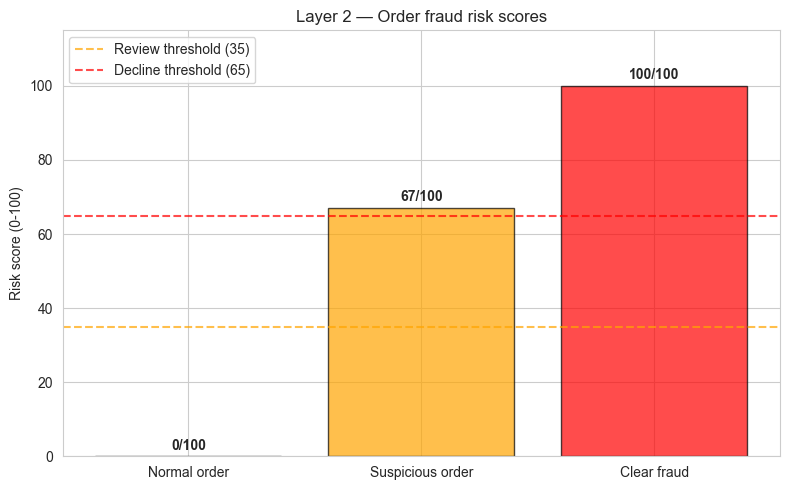

In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — VISUALISE SCENARIO SCORES
# A simple bar chart comparing the three scenario risk scores.
# This is the kind of chart you put in your README.
# ─────────────────────────────────────────────────────────────

scenario_names = ["Normal order", "Suspicious order", "Clear fraud"]
scores = [0, 67, 100]
colors = ["green", "orange", "red"]

plt.figure(figsize=(8, 5))
bars = plt.bar(scenario_names, scores, color=colors, alpha=0.7, edgecolor="black")

# Add score labels on top of each bar
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{score}/100",
        ha="center", va="bottom", fontweight="bold"
    )

# Add decision threshold lines
plt.axhline(y=35, color="orange", linestyle="--", alpha=0.7, label="Review threshold (35)")
plt.axhline(y=65, color="red", linestyle="--", alpha=0.7, label="Decline threshold (65)")

plt.title("Layer 2 — Order fraud risk scores")
plt.ylabel("Risk score (0-100)")
plt.ylim(0, 115)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — COMBINED LAYER 1 + LAYER 2 SCORE
# In a real system both layers run on every transaction.
# We combine them into one final risk score.
#
# Layer 1 (card fraud)  → XGBoost probability (0 to 1)
# Layer 2 (order fraud) → Rule score (0 to 100)
#
# Final score = weighted average:
# 60% weight on Layer 1 (ML model — more precise)
# 40% weight on Layer 2 (rules — catches behavioural fraud)
# ─────────────────────────────────────────────────────────────

def combined_score(layer1_proba: float, layer2_score: int) -> dict:
    """
    Combines Layer 1 ML probability and Layer 2 rule score
    into a single final risk score and decision.

    Args:
        layer1_proba: XGBoost fraud probability (0.0 to 1.0)
        layer2_score: Order fraud rule score (0 to 100)

    Returns:
        dict with final score, decision, and breakdown
    """
    # Convert Layer 1 probability to 0-100 scale
    layer1_score = layer1_proba * 100

    # Weighted combination
    final_score = int((layer1_score * 0.6) + (layer2_score * 0.4))
    final_score = min(final_score, 100)

    # Decision
    if final_score < 35:
        decision = "APPROVE"
    elif final_score < 65:
        decision = "REVIEW"
    else:
        decision = "DECLINE"

    return {
        "layer1_score"  : round(layer1_score, 1),
        "layer2_score"  : layer2_score,
        "final_score"   : final_score,
        "decision"      : decision
    }


# Test with realistic combinations
test_cases = [
    ("Clean card + normal order",       0.02, 0),
    ("Clean card + suspicious order",   0.05, 67),
    ("Suspicious card + normal order",  0.72, 10),
    ("Fraud card + fraud order",        0.95, 100),
    ("Fraud card bypasses Layer 1",     0.10, 95),  # key scenario
]

print(f"{'Case':<40} {'L1':>6} {'L2':>6} {'Final':>7} {'Decision'}")
print("─" * 75)

for name, l1_proba, l2_score in test_cases:
    result = combined_score(l1_proba, l2_score)
    print(f"{name:<40} {result['layer1_score']:>5.1f}  "
          f"{result['layer2_score']:>5}  "
          f"{result['final_score']:>6}  "
          f"{result['decision']}")

Case                                         L1     L2   Final Decision
───────────────────────────────────────────────────────────────────────────
Clean card + normal order                  2.0      0       1  APPROVE
Clean card + suspicious order              5.0     67      29  APPROVE
Suspicious card + normal order            72.0     10      47  REVIEW
Fraud card + fraud order                  95.0    100      97  DECLINE
Fraud card bypasses Layer 1               10.0     95      44  REVIEW


## Layer 2 Conclusions

### Scoring engine signals
| Signal | Max points | Risk level |
|---|---|---|
| Linked to prior fraud | 25 | Critical |
| Account created today | 22 | High |
| Shipping to high-risk country | 22 | High |
| Multiple cards tried | 20 | High |
| Freight forwarder address | 20 | High |
| IP velocity (5+ orders) | 20 | High |
| Disposable email | 18 | High |
| Address added recently | 18 | High |
| VPN detected | 15 | High |
| Name mismatch | 15 | High |

### Combined scoring weights
| Layer | Weight | Reason |
|---|---|---|
| Layer 1 — XGBoost ML model | 60% | More precise — trained on real transaction data |
| Layer 2 — Rule scoring engine | 40% | Catches behavioural fraud ML cannot see |

### Key insight
A stolen card with a low Layer 1 score (looks clean) but high
Layer 2 score (suspicious behaviour) still gets flagged for REVIEW.
This is the core value of the two-layer architecture.

**Next step:** Build the Streamlit app to demo both layers interactively.